In [6]:
import pandas as pd
import numpy as np

df=pd.read_csv("creditcard.csv")

req=df[["Amount"]]
df.drop(["Class","Amount"],axis=1,inplace=True)

In [15]:
df=pd.read_csv("creditcard.csv")
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scaled_v28=scalar.fit_transform(df)
scaled_amount=scalar.fit_transform(req)

from sklearn.decomposition import PCA
pca=PCA(n_components=1)
df=pca.fit_transform(scaled_v28)

df=pd.DataFrame(df)
df["Amount"]=req

In [3]:
import matplotlib.pyplot as plt
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


Text(0, 0.5, 'amount')

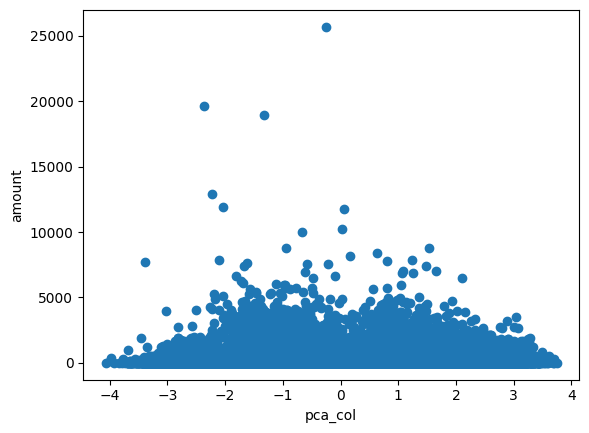

In [8]:
plt.scatter(df[0],df["Amount"])
plt.xlabel("pca_col")
plt.ylabel("amount")

Text(0, 0.5, 'amount')

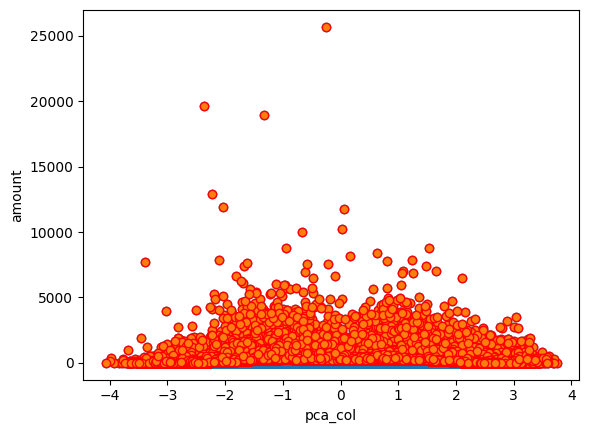

In [9]:
df.columns = df.columns.astype(str)

from sklearn.ensemble import IsolationForest
If=IsolationForest(contamination="auto")

If.fit(df)

predictions=If.predict(df)

index=np.where(predictions<0)

x=df.values

plt.scatter(df["0"],df["Amount"])
plt.scatter(x[index,0],x[index,1],edgecolors="r")
plt.xlabel("pca_col")
plt.ylabel("amount")

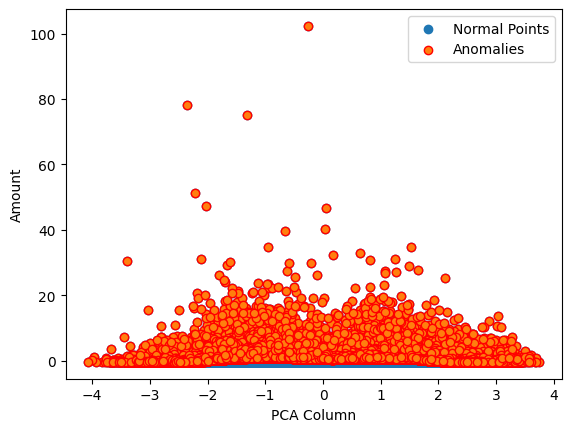

In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("creditcard.csv")

# Separate the 'Amount' column
req = df[["Amount"]]
df.drop(["Class", "Amount"], axis=1, inplace=True)

# Scale the data
scaler = StandardScaler()
scaled_v28 = scaler.fit_transform(df)
scaled_amount = scaler.fit_transform(req)

# Apply PCA
pca = PCA(n_components=1)
pca_col = pca.fit_transform(scaled_v28)

# Create new DataFrame
df = pd.DataFrame(pca_col, columns=["pca_col"])
df["Amount"] = scaled_amount

# Ensure column names are strings
df.columns = df.columns.astype(str)

# Fit Isolation Forest
If = IsolationForest(contamination="auto")
If.fit(df)

# Predict anomalies
predictions = If.predict(df)

# Get indices of anomalies
index = np.where(predictions < 0)[0]

# Scatter plot
x = df.values
plt.scatter(df["pca_col"], df["Amount"], label="Normal Points")
plt.scatter(x[index, 0], x[index, 1], edgecolors="r", label="Anomalies")
plt.xlabel("PCA Column")
plt.ylabel("Amount")
plt.legend()
plt.show()
